In [131]:
!python --version

Python 3.12.13


In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import joblib

In [133]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [134]:
dataFrame = pd.read_csv('/content/Job_2_resource_Weather Test Data.csv')

In [135]:
dataFrame.shape

(42677, 22)

In [136]:
dataFrame.sample(5)

,row ID,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
12774,Row13120,Wollongong,11.7,20.4,0.0,NaN,NaN,NE,39.0,N,...,20.0,59.0,54.0,1016.8,1009.5,NaN,NaN,17.2,19.5,No
426,Row433,Albury,8.5,16.9,1.2,NaN,NaN,WNW,39.0,N,...,20.0,95.0,64.0,1020.1,1021.5,8.0,8.0,12.0,15.1,Yes
29997,Row30753,Nuriootpa,16.9,37.8,0.0,10.6,13.6,NNE,48.0,NE,...,20.0,28.0,12.0,1017.3,1012.3,0.0,1.0,27.9,36.6,No
25668,Row26359,Cairns,24.5,32.1,0.0,6.2,9.9,NE,28.0,S,...,17.0,70.0,68.0,1010.6,1007.9,3.0,2.0,29.4,31.2,No
37242,Row38141,Walpole,11.1,15.0,0.0,NaN,NaN,NNW,46.0,N,...,13.0,69.0,86.0,1000.7,995.3,NaN,NaN,13.2,14.1,No


This problem is supervised classification problem

In [137]:
dataFrame.isnull().sum()

,0
row ID,0
Location,0
MinTemp,194
MaxTemp,92
Rainfall,427
Evaporation,18312
Sunshine,20499
WindGustDir,2809
WindGustSpeed,2790
WindDir9am,3007


In [138]:
dataFrame.dropna(inplace=True)
dataFrame.shape

(16846, 22)

In [139]:
dataFrame.select_dtypes(include="object").columns

Index(['row ID', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday'],
      dtype='object')

In [140]:
dataFrame = dataFrame.drop(columns=["row ID"], errors="ignore")

In [141]:
le = LabelEncoder()

categorical_cols = [
    'Location',
    'WindGustDir',
    'WindDir9am',
    'WindDir3pm',
    'RainToday'
]

for col in categorical_cols:
    dataFrame[col] = le.fit_transform(dataFrame[col].astype(str))
dataFrame.dtypes

,0
Location,int64
MinTemp,float64
MaxTemp,float64
Rainfall,float64
Evaporation,float64
Sunshine,float64
WindGustDir,int64
WindGustSpeed,float64
WindDir9am,int64
WindDir3pm,int64


In [142]:
X = dataFrame.drop("RainToday", axis=1)
y = dataFrame["RainToday"]

In [143]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [144]:
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [145]:
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9875


In [146]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [147]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

accuracy_dt = dt_model.score(X_test_scaled, y_test)
print(f"Decision Tree Accuracy with scaled data: {accuracy_dt:.4f}")

Decision Tree Accuracy with scaled data: 1.0000


In [148]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

accuracy_rf = rf_model.score(X_test_scaled, y_test)
print(f"Random Forest Accuracy with scaled data: {accuracy_rf:.4f}")

Random Forest Accuracy with scaled data: 1.0000


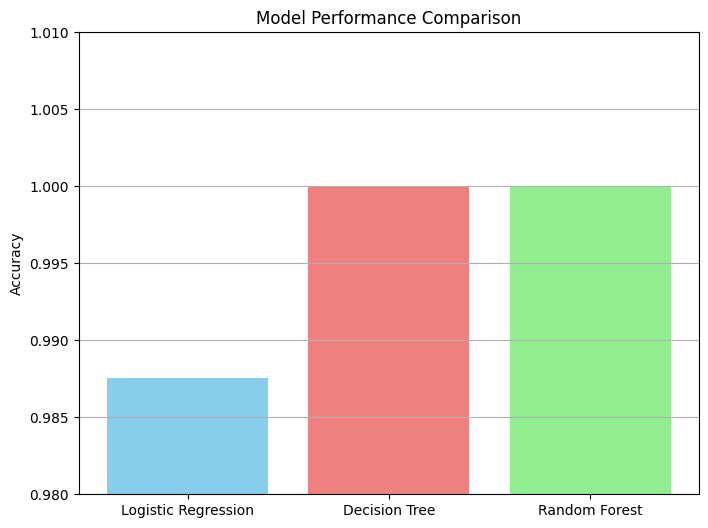

In [149]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [accuracy, accuracy_dt, accuracy_rf]
colors = ['skyblue', 'lightcoral', 'lightgreen']

plt.figure(figsize=(8, 6))
plt.bar(models, accuracy, color=colors)
plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.98, 1.01)
plt.grid(axis='y')
plt.savefig("model performance comparison.pdf")
plt.show()

In [150]:
joblib.dump(model, 'logistic_regression_model.joblib')
joblib.dump(dt_model, 'decision_tree_model.joblib')
joblib.dump(rf_model, 'random_forest_model.joblib')


['random_forest_model.joblib']